# Max-Cut with VQE (4 Qubits)

In this module, you will:
- Understand the **Variational Quantum Eigensolver (VQE)** — a leading hybrid quantum-classical algorithm for finding ground-state energies of Hamiltonians.
- Learn the **mathematical formulation** of the Max-Cut problem: how a graph partitioning objective is encoded into a cost Hamiltonian suitable for quantum optimization.
- Build and run VQE using the QpiAI Quantum SDK — configuring the `MaxCutProblem`, the `VQESolver`, and interpreting the results.
- Analyze the optimization landscape, convergence behaviour, and the decoded graph partition for a **4-node graph**.

## What is Max-Cut?

Given a graph $G = (V, E)$ with edge weights $w_{ij}$, we assign one variable to each node:

$$z_i \in \{-1, +1\}$$

If two connected nodes are in different groups, the edge contributes to the cut.

The total cut value is:

$$C(z) = \frac{1}{2} \sum_{(i,j)\in E} w_{ij} \left( 1 - z_i z_j \right)$$

Our goal is to **maximize** $C(z)$.

VQE is a flexible variational framework that can tackle a wide range of optimization and chemistry problems. In this notebook we apply it to the **Max-Cut** combinatorial optimization problem on a 4-node graph.

**Key Insight:** Each qubit represents one node. The algorithm explores $2^n$ possible partitions in superposition and converges on the one that maximizes the number of cut edges.

## 1. Setup & Authentication

We reuse the same authentication pattern as previous modules: load `API_KEY` from `qcloud.env` and authenticate with `QpiAIQuantumAuth`.

In [ ]:
import os

from dotenv import load_dotenv
from qpiai_quantum import QpiAIQuantumAuth

load_dotenv("./qcloud.env") # This path should point to the env file containing your API key.

QpiAIQuantumAuth.login(os.getenv("API_KEY"))
user_info = QpiAIQuantumAuth.me()

print(f"✅ Authenticated successfully as: {user_info.get('name', 'User')} ({user_info.get('email', '')})")

✅ Authenticated successfully as: Test Advanced User (test_advanced@qpiai.tech)


## 2. SDK Primitives Used (This Module)

- `MaxCutProblem` — encodes a graph's edge structure and weights into a QUBO / Ising cost Hamiltonian for VQE.
- `VQESolver` — implements the VQE variational loop: ansatz circuit construction, measurement, expectation-value computation, and classical parameter update.
- **Solver configuration:** `ansatz`, `optimizer`, `max_iterations`.
- **Execution:** `solver.run(hamiltonian, shots, experiment_name, device_name)`.
- **Results:** `result.optimal_energy`, `result.bitstring`, `result.energy_history`, `result.metadata`.
- **Post-processing:** `problem.decode_solution()`, `problem.validate_solution()`, `problem.compute_solution_quality()`.

We will first review the problem setup, then configure the solver and interpret the output.

## 3. Theory: The Max-Cut Cost Hamiltonian

To solve the Max-Cut problem using a quantum algorithm, we map the classical variables to qubits:

$$z_i \rightarrow Z_i$$

The Max-Cut cost Hamiltonian becomes:

$$H_C = \frac{1}{2} \sum_{(i,j)\in E} w_{ij} \left( I - Z_i Z_j \right)$$

Minimizing the expectation value of $H_C$ is equivalent to maximizing the cut.

### Variational Quantum State

We prepare a parameterized quantum state (ansatz):

$$|\psi(\boldsymbol{\theta})\rangle = U(\boldsymbol{\theta}) |0\rangle^{\otimes n}$$

Here, $\boldsymbol{\theta}$ are tunable parameters of the circuit.

### VQE Objective Function

The quantity minimized by VQE is:

$$E(\boldsymbol{\theta}) = \langle \psi(\boldsymbol{\theta}) | H_C | \psi(\boldsymbol{\theta}) \rangle$$

The optimal parameters are:

$$\boldsymbol{\theta}^* = \arg\min_{\boldsymbol{\theta}} E(\boldsymbol{\theta})$$

A classical optimizer iteratively adjusts $\boldsymbol{\theta}$ using the measured expectation values until convergence.

## 4. Define the Max-Cut Problem (4 Qubits)

We construct a Max-Cut problem on a **4-node graph**, where each node is represented by one qubit.

The graph has 5 edges forming a "square with one diagonal":

```
 0 ── 1
 |  ╲ |
 3 ── 2
```

| Edge | Weight |
|:---:|:---:|
| (0, 1) | 1 |
| (1, 2) | 1 |
| (2, 3) | 1 |
| (3, 0) | 1 |
| (0, 2) | 1 |

With 4 qubits the search space has $2^4 = 16$ possible partitions — small enough to verify classically, but the same algorithm scales to larger instances on quantum hardware.

In [2]:
from qpiai_quantum.algorithms.opt.solvers.vqe import VQESolver
from qpiai_quantum.algorithms.opt.problems import MaxCutProblem
import numpy as np
import networkx as nx

graph = nx.Graph()
graph.add_edges_from([(0, 1), (1, 2), (2, 3), (3, 0), (0, 2)])

maxcut_problem = MaxCutProblem(graph)

print(f"Problem: Max-Cut with VQE (4 Qubits)")
print(f"Nodes: {graph.number_of_nodes()}")
print(f"Edges: {list(graph.edges())}")
print(f"Number of edges: {graph.number_of_edges()}")
print(f"Qubits needed: {maxcut_problem.n_qubits}")

Problem: Max-Cut with VQE (4 Qubits)
Nodes: 4
Edges: [(0, 1), (0, 3), (0, 2), (1, 2), (2, 3)]
Number of edges: 5
Qubits needed: 4


## 5. Examine the Hamiltonian

The SDK converts the graph structure into Pauli Hamiltonian terms automatically using `get_hamiltonian_terms()`.

Each edge $(i, j)$ with weight $w_{ij}$ contributes a $Z_i Z_j$ term with coefficient $w_{ij}/2$ to the cost Hamiltonian. Let's inspect the terms:

In [3]:
terms = maxcut_problem.get_hamiltonian_terms()
print(f"\nTotal Hamiltonian terms: {len(terms)}")
print(f"\nHamiltonian terms:")
for i, (ops, coeff) in enumerate(terms):
    if ops:
        op_str = " ".join([f"{op}_{qi}" for qi, op in ops])
    else:
        op_str = "Identity (constant)"
    print(f"  Term {i:2d}: {op_str:35s} coeff={coeff:9.5f}")


Total Hamiltonian terms: 6

Hamiltonian terms:
  Term  0: Z_0 Z_1                             coeff=  0.50000
  Term  1: Z_0 Z_3                             coeff=  0.50000
  Term  2: Z_0 Z_2                             coeff=  0.50000
  Term  3: Z_1 Z_2                             coeff=  0.50000
  Term  4: Z_2 Z_3                             coeff=  0.50000
  Term  5: Identity (constant)                 coeff=  2.50000


## 6. Configure VQE Solver

We create a `VQESolver` with the following settings:

| Parameter | Value | Description |
|:---|:---|:---|
| `n_qubits` | 4 | Number of qubits = number of graph nodes |
| `ansatz` | `'standard'` | Standard parameterized ansatz |
| `optimizer` | `'spsa'` | SPSA optimizer — gradient-free, well suited for noisy landscapes |
| `max_iterations` | 5 | Number of classical optimization iterations |

The SPSA optimizer uses stochastic perturbations to estimate gradients, making it efficient for quantum circuits where each evaluation is expensive.

In [4]:
solver = VQESolver(
    n_qubits=maxcut_problem.n_qubits,
    hamiltonian=maxcut_problem,
    ansatz='standard',
    optimizer='spsa',
    max_iterations=500,
)

print(f"\nVQE Configuration:")
print(f"  Qubits: {maxcut_problem.n_qubits}")
print(f"  Ansatz: {solver.ansatz}")
print(f"  Optimizer: {solver.optimizer}")
print(f"  Max Iterations: {solver.max_iterations}")


VQE Configuration:
  Qubits: 4
  Ansatz: standard
  Optimizer: spsa
  Max Iterations: 500


## 7. Run VQE Optimization

We now execute the VQE algorithm on QpiAI's quantum simulator.

The algorithm will:
1. Initialize ansatz parameters $\boldsymbol{\theta}$.
2. Build the parameterized circuit.
3. Execute the circuit and measure results.
4. Compute the expectation value of the cost Hamiltonian.
5. Update parameters using the SPSA optimizer.
6. Repeat until convergence or `max_iterations`.

> **Simulator default:** `device_name='QpiAI-QSV-Local'`. To run on a QPU, change to `device_name='QpiAI-Indus-1'` and configure an experiment with the same name in the QpiAI web UI.

This may take a few minutes depending on the number of iterations.

> **Note:** The `experiment_name` parameter is omitted here because it is only required for cloud executions (e.g., on QCloud simulators or Indus QPU). For local simulation (`QpiAI-QSV-Local`), it is not needed.


In [5]:
# Note: experiment_name is only required for cloud executions
result = solver.run(
    shots=10000,
    device_name='QpiAI-QSV-Local',
)

print(f"\n" + "="*70)
print("VQE RESULTS SUMMARY")
print("="*70)
print(f"Optimal energy: {result.optimal_energy:.6f}")
print(f"Best bitstring: {result.bitstring}")
print(f"Iterations: {len(result.energy_history)}")
print(f"Success: {result.metadata['success']}")


VQE OPTIMIZATION STARTING
Optimizer:        SPSA
Parameters:       24
Max Iterations:   500
Shots per eval:   10000
Expected Evals:   ~1501 (may stop early if converged)
  |-- 1 initial + 500 iterations x 3 evals/iter

Note: Optimizer may stop earlier if convergence criteria are met.


VQE OPTIMIZATION COMPLETED
Actual Iterations:   95
Max Iterations:      500
Circuit Evaluations: 286
Final Energy:        1.014000
Success:             True

 Note: Optimizer converged early (stopped at iteration 95)


VQE RESULTS SUMMARY
Optimal energy: 1.014000
Best bitstring: 0101
Iterations: 96
Success: True


## 8. Decode and Validate Solution

The solver returns a bitstring encoding the graph partition. Let's decode it and evaluate the quality of the cut:

**Reading the bitstring:**
- Each bit corresponds to a node (bit 0 → Node 0, bit 1 → Node 1, etc.).
- Nodes with `0` are placed in **Partition 0**; nodes with `1` in **Partition 1**.
- An edge contributes to the cut if and only if its endpoints are in different partitions.

In [6]:
print(f"\n" + "="*70)
print("MAX-CUT PARTITION")
print("="*70)

solution = maxcut_problem.decode_solution(result.bitstring)
is_valid, msg = maxcut_problem.validate_solution(solution)
quality = maxcut_problem.compute_solution_quality(solution)

print(f"\nBest bitstring: {result.bitstring}")
print(f"Partition 0: {solution['partition_0']}")
print(f"Partition 1: {solution['partition_1']}")

print(f"\nValidation: {msg}")
print(f"Is valid: {is_valid}")

print(f"\nCut value: {quality['cut_value']:.0f} / {graph.number_of_edges()}")
print(f"Cut ratio: {quality['cut_ratio']:.2%}")
print(f"Balance ratio: {quality['balance_ratio']:.2%}")

print(f"\nDetailed Partition:")
for node in sorted(graph.nodes()):
    group = "Partition 0" if node in solution['partition_0'] else "Partition 1"
    marker = "\u2705" if node in solution['partition_1'] else "  "
    print(f"  Node {node}: {marker} {group}")


MAX-CUT PARTITION

Best bitstring: 0101
Partition 0: [1, 3]
Partition 1: [0, 2]

Validation: Valid MaxCut solution
Is valid: True

Cut value: 4 / 5
Cut ratio: 80.00%
Balance ratio: 100.00%

Detailed Partition:
  Node 0: ✅ Partition 1
  Node 1:    Partition 0
  Node 2: ✅ Partition 1
  Node 3:    Partition 0


## 9. Visualize Optimization Progress

The SDK provides a comprehensive visualization function `plot_vqe_results_comprehensive()` to analyze the optimization trajectory and the final measurement landscape.

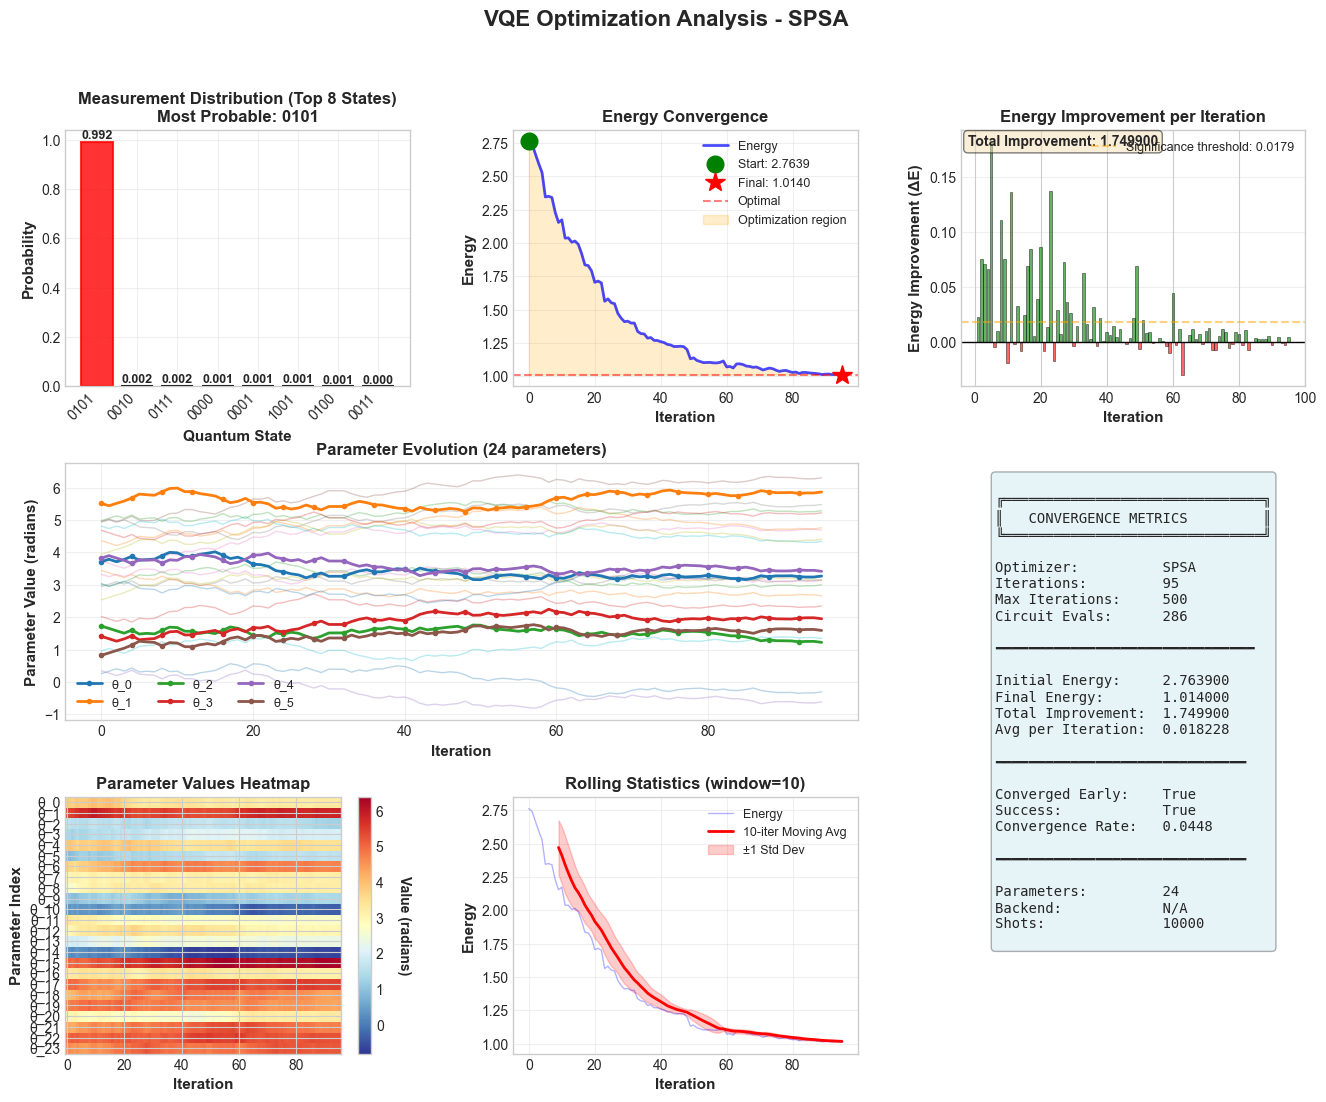

In [7]:
from qpiai_quantum.algorithms import plot_vqe_results_comprehensive

plot_vqe_results_comprehensive(result)

### Graph Partition

Let's also plot the resulting graph partition:

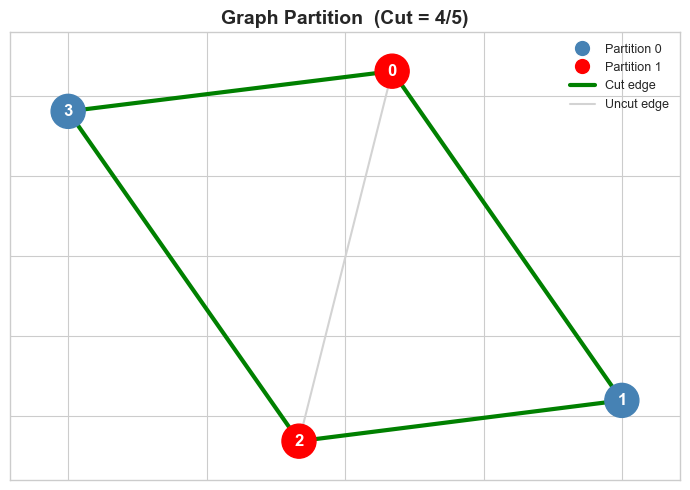

In [8]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 5))

pos = nx.spring_layout(graph, seed=42)
partition_0 = solution['partition_0']
partition_1 = solution['partition_1']

# Color nodes by partition
node_colors = ['steelblue' if n in partition_0 else 'red' for n in graph.nodes()]

# Color edges: cut edges in green, uncut in gray
edge_colors = []
edge_widths = []
for u, v in graph.edges():
    if (u in partition_0 and v in partition_1) or (u in partition_1 and v in partition_0):
        edge_colors.append('green')
        edge_widths.append(3.0)
    else:
        edge_colors.append('lightgray')
        edge_widths.append(1.5)

nx.draw_networkx(graph, pos, ax=ax, node_color=node_colors, node_size=600,
                 edge_color=edge_colors, width=edge_widths, font_color='white',
                 font_weight='bold')
ax.set_title(f'Graph Partition  (Cut = {quality["cut_value"]:.0f}/{graph.number_of_edges()})',
             fontsize=14, fontweight='bold')
ax.legend(
    handles=[
        plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='steelblue',
                   markersize=12, label='Partition 0'),
        plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='red',
                   markersize=12, label='Partition 1'),
        plt.Line2D([0],[0], color='green', linewidth=3, label='Cut edge'),
        plt.Line2D([0],[0], color='lightgray', linewidth=1.5, label='Uncut edge'),
    ],
    loc='upper right', fontsize=9
)

plt.tight_layout()
plt.show()

### Results Interpretation

**Reading the bitstring:**
- Each bit position corresponds to a graph node.
- Nodes assigned `0` are in **Partition 0** (blue); nodes assigned `1` are in **Partition 1** (red).
- The number of green edges in the graph plot equals the **cut value**.

**Energy:**
- Lower energy corresponds to a larger cut value.
- The energy convergence plot shows how the VQE optimizer refines $\boldsymbol{\theta}$ across iterations.

**Solution quality:**
- `cut_ratio` = cut edges / total edges. A ratio of 1.0 means every edge is cut (only possible in bipartite graphs).
- `balance_ratio` indicates how evenly nodes are distributed between the two partitions.

**On a noisy QPU:** The optimal bitstring should still dominate, but noise introduces contributions from sub-optimal states.

## 10. Exercises

**Beginner:**

1. Remove the diagonal edge `(0, 2)` to make the graph a simple 4-cycle. What is the optimal cut value? Does VQE find it?
2. Add weights to the edges (e.g., `graph.add_edge(0, 1, weight=2.0)`) and re-run. How does the solution change?

**Intermediate:**

3. Increase `max_iterations` to 10 or 20 and compare the final energy. At what point does the optimizer converge?
4. Change the optimizer from `'spsa'` to `'cobyla'` and compare results. Which converges faster for this 4-node graph?

**Advanced:**

5. Extend the graph to 5 or 6 nodes. How does the solution space grow ($2^5 = 32$, $2^6 = 64$ states)? Run with increasing `max_iterations` and report convergence.
6. Compare the VQE solution on this graph with the QAOA approach (see the Portfolio QAOA notebook). Which converges faster? Which produces a better final energy?

## 11. Key Takeaways

- **VQE** is a flexible hybrid quantum-classical framework that minimizes the expectation value of a Hamiltonian using a parameterized quantum circuit.
- The **Max-Cut** cost Hamiltonian is constructed from $Z_i Z_j$ terms — one per edge — making it a natural fit for qubit-based optimization.
- With 4 nodes, the search space has $2^4 = 16$ possible partitions — small enough to verify classically, but the same algorithm scales to much larger instances on quantum hardware.
- The QpiAI SDK provides `MaxCutProblem` for automatic Hamiltonian construction and `VQESolver` for the full variational loop.
- The SPSA optimizer is well suited for noisy quantum circuits because it does not require exact gradient evaluation.
- On a **statevector simulator**, results are noiseless. On real hardware, noise may degrade the optimal bitstring probability.

---
**Thank you for learning with QpiAI!**

In [9]:
import qpiai_quantum
print(f"QpiAI Quantum SDK version: {qpiai_quantum.__version__}")

QpiAI Quantum SDK version: 0.1.40
